In [31]:
import sys
!{sys.executable} -m pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 8.2 MB/s  0:00:01m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]

[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip


In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("car data.csv") # 데이터 불러오기

In [ ]:
df.head() 

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [ ]:
df.shape # 301개 데이터, 8개 피처 보유 (1개는 target)

(301, 9)

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Selling_type   301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 21.3 KB


In [19]:
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


#### 피처별 전처리 계획
1. 범주형 피처   
**Car_Name** : 자동차의 종류도 너무 많고, 텍스트 데이터를 아직은 모델이 학습하기 어려우므로 피처 삭제.  
**Owner** : 자동차 소유자 수, 0명인 경우가 대부분이고 1명 이상인 경우는 11가지 뿐이므로 이상치로 판단하여 피처 삭제.  
**Fuel_type** : 연료 종류(Petrol, Diesel, CNG 3가지) -> Onehot encoding.  
**Selling_type** : 판매 유형(Dealer, Individual 2가지) -> Onehot encoding.  
**Transmission** : 자동차 운전 방식(Manual, Automatic) -> Onehot encoding
   
2. 연속형 피처   
**Year** : 자동차가 출시된 연도, 최대가 2018이므로 `2018-출시 년도`를 계산해서 Age 칼럼을 새로 만들기  
**Present_Price** : 이 자동차의 현재 가격, 이상치(92.6) 1개 삭제   
**Driven_kms** : 주행 거리, 이상치(500000) 1개 삭제    

In [ ]:
# Age 칼럼 만들기
df['Age'] = 2018-df['Year']

# Car_Name, Owner, Year 삭제
df.drop(columns=['Car_Name', 'Owner', 'Year'], inplace=True)

# 잘 삭제됐는지 확인
df.head()

,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Age
0,3.35,5.59,27000,Petrol,Dealer,Manual,4
1,4.75,9.54,43000,Diesel,Dealer,Manual,5
2,7.25,9.85,6900,Petrol,Dealer,Manual,1
3,2.85,4.15,5200,Petrol,Dealer,Manual,7
4,4.60,6.87,42450,Diesel,Dealer,Manual,4


In [23]:
# 연속형 피처 이상치 행 삭제
df.drop(df[df['Present_Price'] == 92.6].index, inplace=True)
df.drop(df[df['Driven_kms'] == 500000].index, inplace=True)

# 잘 삭제됐는지 확인
df.describe()

,Selling_Price,Present_Price,Driven_kms,Age
count,299.000000,299.000000,299.000000,299.000000
mean,4.574849,7.368060,35261.234114,4.341137
std,4.779588,7.122446,28183.470787,2.875028
min,0.100000,0.320000,500.000000,0.000000
25%,0.900000,1.230000,15000.000000,2.000000
50%,3.600000,6.400000,32000.000000,4.000000
75%,6.000000,9.875000,47500.000000,6.000000
max,33.000000,36.230000,213000.000000,15.000000


In [25]:
# Onehot encoding
df = pd.get_dummies(
    df, 
    columns=['Fuel_Type', 'Selling_type', 'Transmission'], 
    drop_first=True, 
    dtype=int
)

df.head()

,Selling_Price,Present_Price,Driven_kms,Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual
0,3.35,5.59,27000,4,0,1,0,1
1,4.75,9.54,43000,5,1,0,0,1
2,7.25,9.85,6900,1,0,1,0,1
3,2.85,4.15,5200,7,0,1,0,1
4,4.60,6.87,42450,4,1,0,0,1


#### 연속형 피처 스케일링
현재 데이터에서 연속형 피처는 'Present_Price', 'Driven_kms', 'Age' 세 가지이다. 세 피처들의 단위를 맞추기 위해 우선 분포를 확인했더니 모두 왜도가 심한 분포를 보였다. 따라서 **로그 변환 후 표준화**로 스케일링해준다.   
**로그 변환** : 로그를 취하면 큰 값들은 확 줄어들고 작은 값들은 촘촘하게 펴진다. 따라서 분포를 정규분포로 변환할 수 있다.

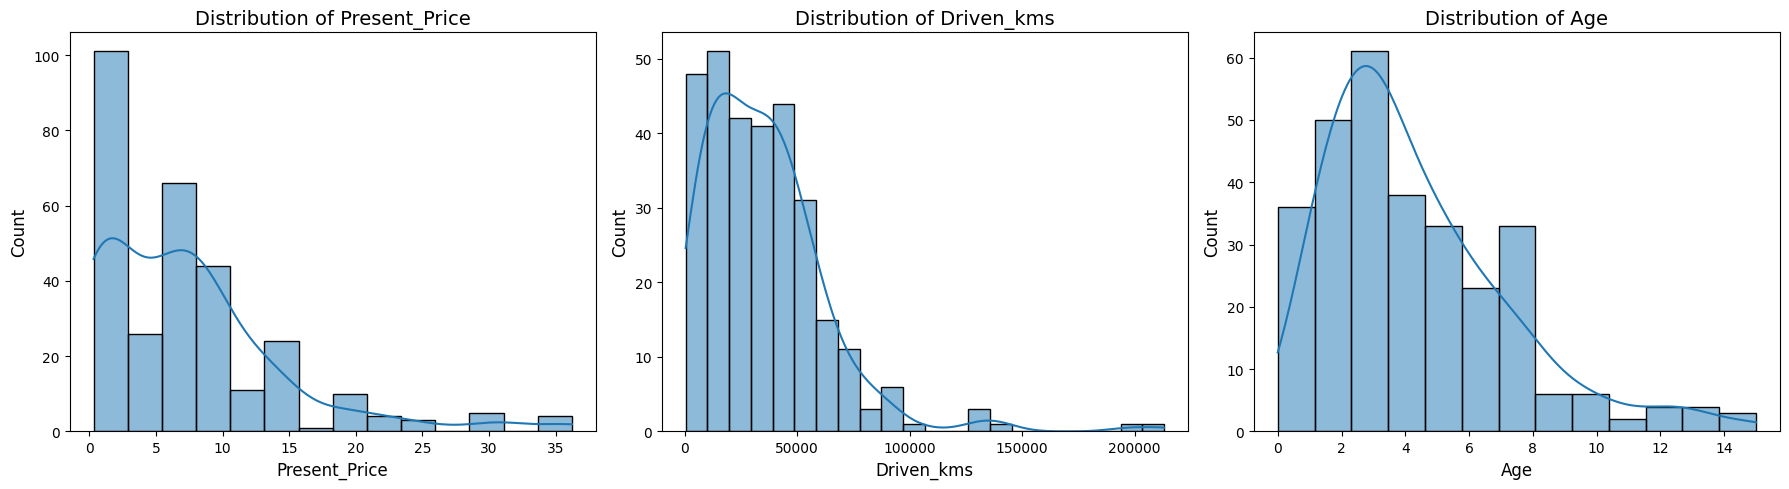

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 시각화할 연속형 피처 리스트 지정
numerical_cols = ['Present_Price', 'Driven_kms', 'Age']

# 1행 3열로 3개의 그래프 배치
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))

# 반복문을 돌며 각 피처의 분포를 히스토그램+KDE 곡선으로 그리기
for i, col in enumerate(numerical_cols):
    sns.histplot(data=df, x=col, kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}', fontsize=14)
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel('Count', fontsize=12)

# 4. 그래프 간격 조절 및 출력
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# 원본 데이터 복사
df_processed = df.copy()

# 로그 변환으로 왜도 줄이기
for col in numerical_cols:
    df_processed[col] = np.log1p(df_processed[col])

# 로그 변환된 데이터에 표준화 함수 StandardScaler 적용
scaler = StandardScaler()
df_processed[numerical_cols] = scaler.fit_transform(df_processed[numerical_cols])

df_processed.head()


,Selling_Price,Present_Price,Driven_kms,Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual
0,3.35,0.134097,0.098951,0.129216,0,1,0,1
1,4.75,0.665046,0.565317,0.482976,1,0,0,1
2,7.25,0.697819,-1.268238,-1.648669,0,1,0,1
3,2.85,-0.144655,-1.551671,1.041167,0,1,0,1
4,4.60,0.334781,0.552416,0.129216,1,0,0,1


#### train, test split 하고 모델학습하기, 성능 확인

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# x, y 분리
X = df_processed.drop(columns=['Selling_Price'])
y = df_processed['Selling_Price']

# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Linear Regression 모델 생성, 학습
model = LinearRegression()
model.fit(X_train, y_train)

# 예측
y_pred = model.predict(X_test)

# 성능 평가
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("--- 모델 평가 결과 ---")
print(f"MSE: {mse:.4f}")
print(f"R2 score: {r2:.4f}")

--- 모델 평가 결과 ---
MSE: 6.0455
R2 score: 0.8109


#### 각 피처의 회귀계수 확인하기

In [35]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

# 영향력이 큰 순서대로 보기 위해 절대값 기준으로 내림차순 정렬
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='Abs_Coefficient', ascending=False).drop(columns=['Abs_Coefficient'])

# 출력
print("--- 피처별 회귀 계수 (영향력 순) ---")
print(coef_df.to_string(index=False))

--- 피처별 회귀 계수 (영향력 순) ---
                Feature  Coefficient
          Present_Price     4.232800
       Fuel_Type_Diesel     2.535077
Selling_type_Individual     2.363443
    Transmission_Manual    -2.143645
                    Age    -1.096827
       Fuel_Type_Petrol     0.443301
             Driven_kms    -0.288834


#### 결과 해석
1. 회귀 계수가 양수(신차 가격, 연료가 디젤, 개인이 판매, 연료가 가솔린) -> 양의 상관관계
2. 회귀 계수가 음수(수동주행차, 차 나이, 주행거리) -> 음의 상관관계